In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:

# Load dataset
df = pd.read_csv("fertilizer_recommendation_dataset.csv")

# Display first few rows
df.head()


,N (mg/kg),P (mg/kg),K (mg/kg),pH,Moisture (%),EC (dS/m),Temperature (°C),Fertilizer_Recommendation
0,43,32,22,5.38,13,1.06,21,MOP
1,56,29,69,6.53,33,1.87,26,MOP
2,33,43,16,7.53,34,0.71,29,MOP
3,19,37,66,6.47,12,1.23,26,Urea
4,47,5,45,5.34,12,0.80,20,DAP


In [4]:

# Check dataset info
df.info()

# Check class distribution
df['Fertilizer_Recommendation'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   N (mg/kg)                  200 non-null    int64  
 1   P (mg/kg)                  200 non-null    int64  
 2   K (mg/kg)                  200 non-null    int64  
 3   pH                         200 non-null    float64
 4   Moisture (%)               200 non-null    int64  
 5   EC (dS/m)                  200 non-null    float64
 6   Temperature (°C)           200 non-null    int64  
 7   Fertilizer_Recommendation  200 non-null    object 
dtypes: float64(2), int64(5), object(1)
memory usage: 12.6+ KB


Fertilizer_Recommendation
Urea               73
MOP                51
DAP                32
Lime               22
Compost/Organic    16
Gypsum              6
Name: count, dtype: int64

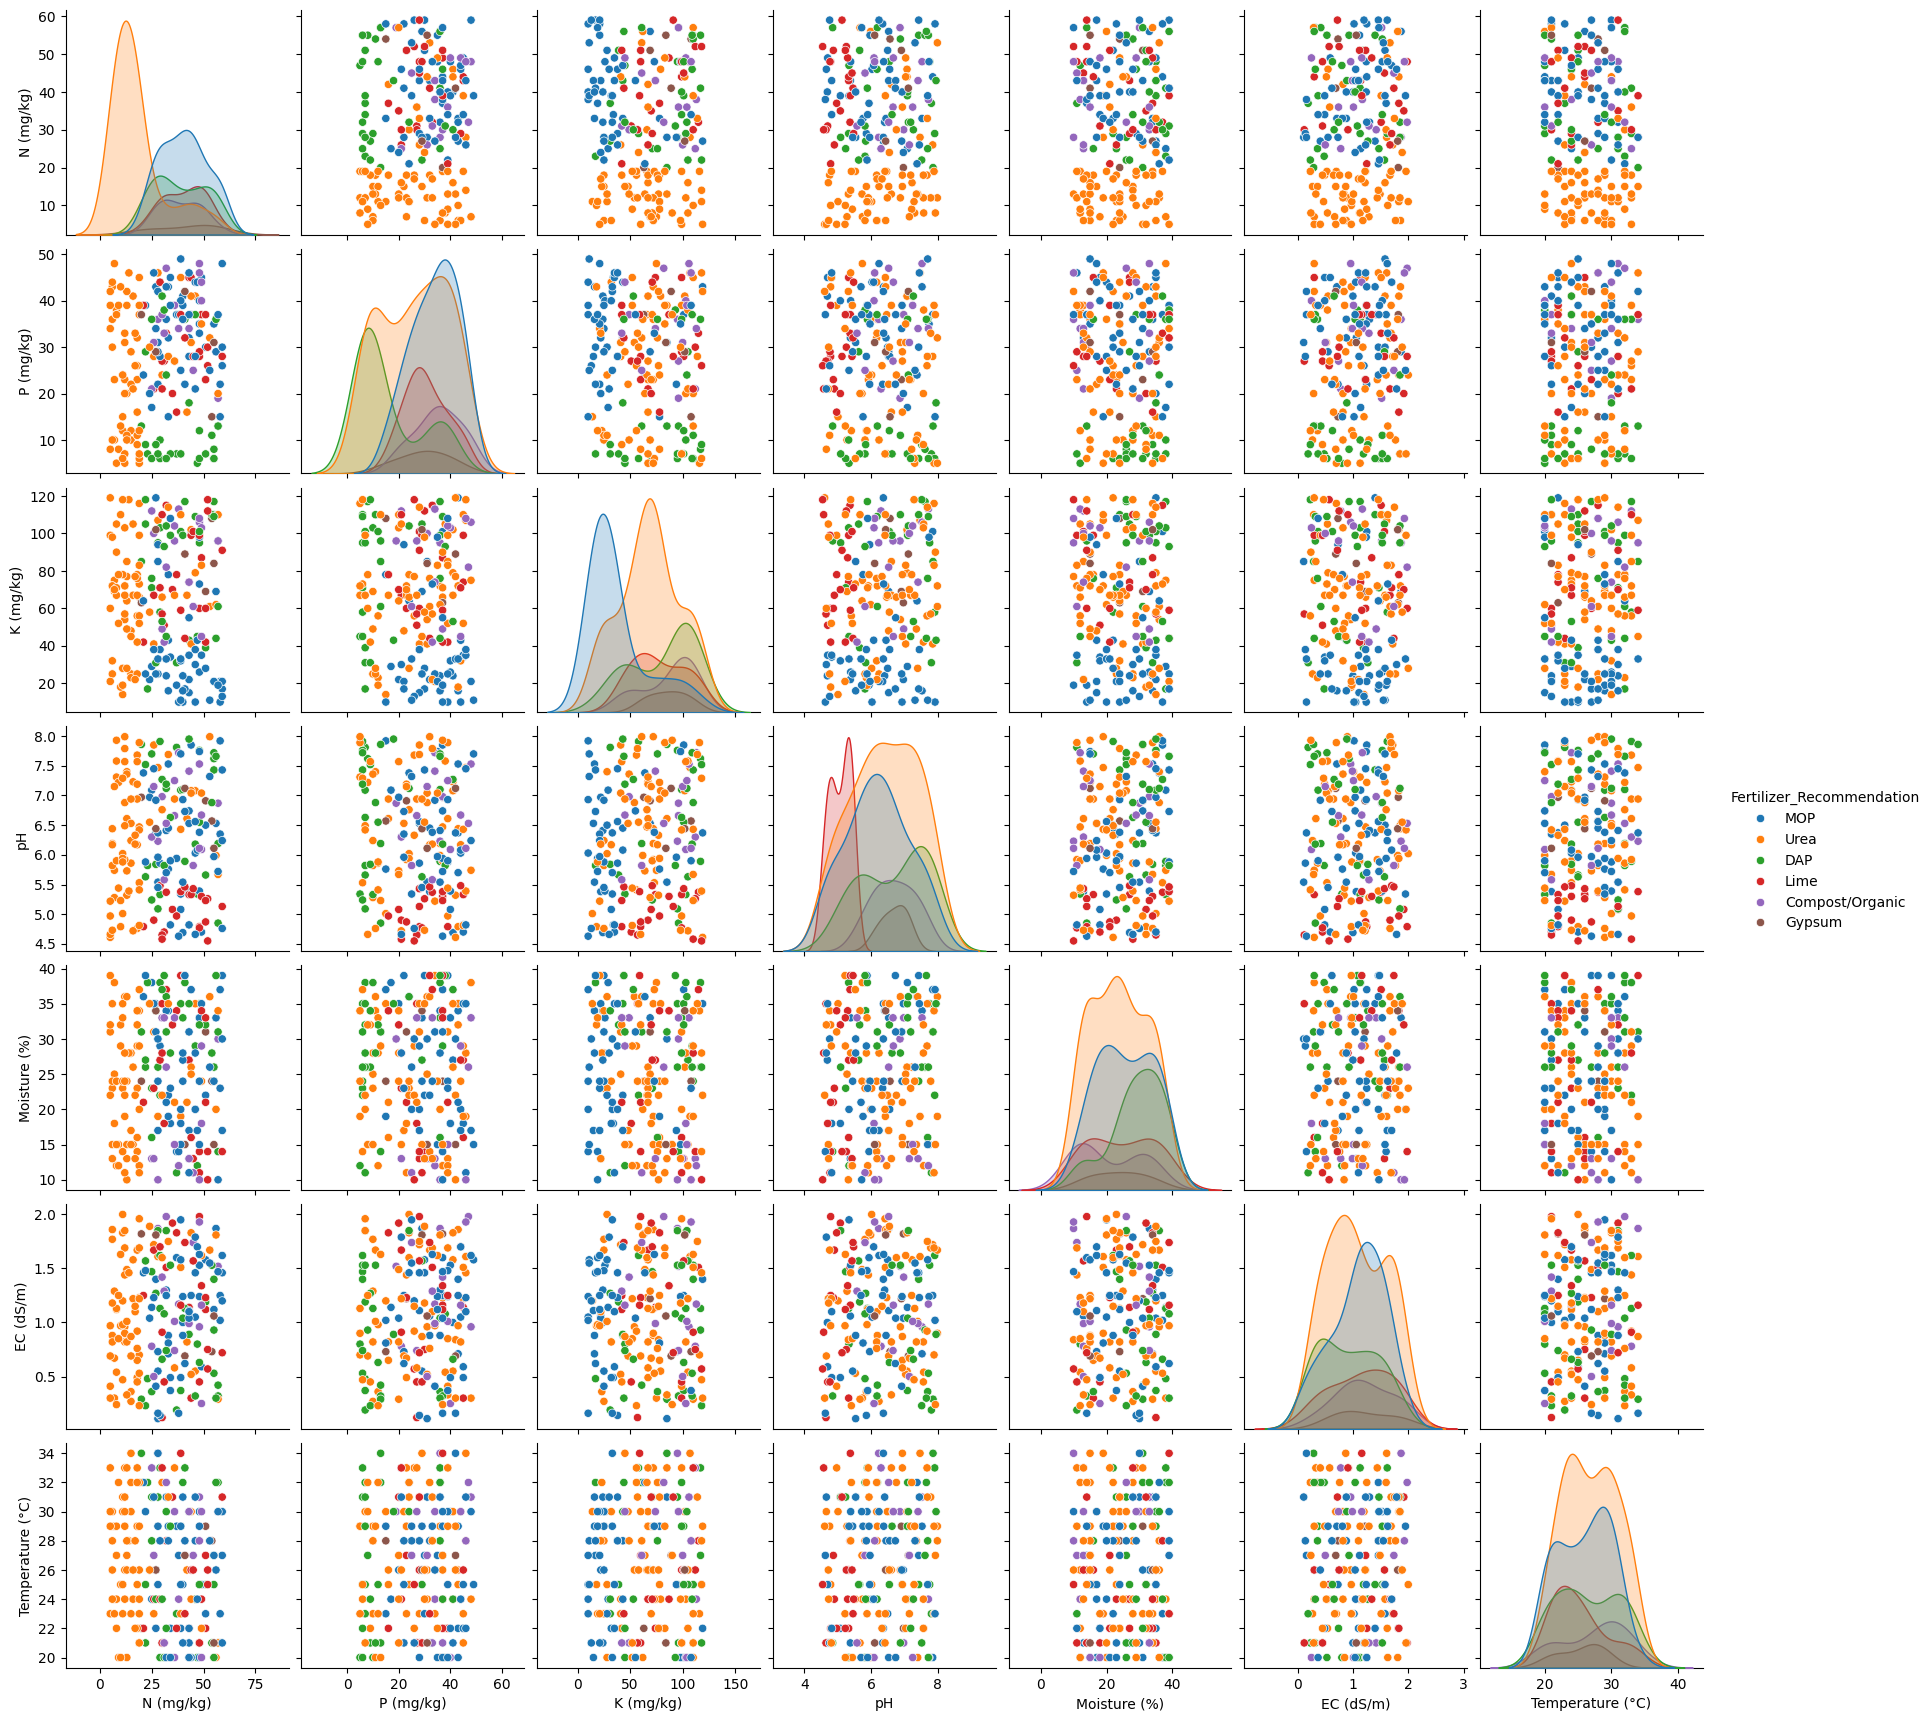

In [5]:

# Pairplot for visualization (optional)
sns.pairplot(df, hue="Fertilizer_Recommendation")
plt.show()


In [6]:

# Features and target
X = df.drop("Fertilizer_Recommendation", axis=1)
y = df["Fertilizer_Recommendation"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [7]:

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Accuracy: 0.75

Classification Report:
                  precision    recall  f1-score   support

Compost/Organic       0.33      0.33      0.33         3
            DAP       0.71      0.71      0.71         7
         Gypsum       0.00      0.00      0.00         1
           Lime       1.00      1.00      1.00         4
            MOP       0.80      0.80      0.80        10
           Urea       0.75      0.80      0.77        15

       accuracy                           0.75        40
      macro avg       0.60      0.61      0.60        40
   weighted avg       0.73      0.75      0.74        40



c:\Users\safid\Downloads\Fertilizer\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\safid\Downloads\Fertilizer\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\safid\Downloads\Fertilizer\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

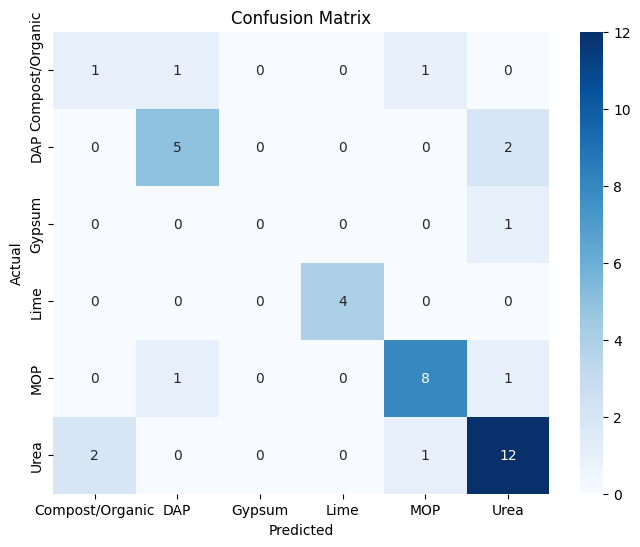

In [8]:

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [9]:

# Example prediction with new soil data
sample_data = np.array([[120, 40, 100, 3, 100, 1.0, 28]])  # N, P, K, pH, Moisture, EC, Temp
sample_data = scaler.transform(sample_data)

predicted_fertilizer = model.predict(sample_data)
print("Recommended Fertilizer:", predicted_fertilizer[0])


Recommended Fertilizer: Lime


c:\Users\safid\Downloads\Fertilizer\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
